# Hierarchical RL: Options Framework

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand hierarchical RL concepts
- Implement options framework
- Build temporally extended actions
- Apply hierarchical RL to complex tasks

## 🔗 Prerequisites

- ✅ Understanding of RL fundamentals
- ✅ Understanding of policies
- ✅ Python knowledge

---

## Official Structure Reference

This notebook covers practical activities from **Course 09, Unit 5**:
- Experimenting with hierarchical RL using options framework

---

## Introduction

**Hierarchical RL** uses temporal abstraction (options) to solve complex tasks by breaking them into subtasks, enabling faster learning and better generalization.

## Lesson Brief

This lesson introduces hierarchical RL through the idea of **options**, or reusable multi-step behaviors.

Students will see how a controller can make higher-level decisions instead of choosing every primitive action one by one.

Why this matters: hierarchical structure is useful when tasks are long, repetitive, or naturally broken into subgoals.

This lesson helps students think about abstraction in RL.

## Recommended YouTube Video

To reinforce this lesson, watch **Universitat Pompeu Fabra - Barcelona - "RLSS 2023: Hierarchical Reinforcement Learning"**:
[Watch on YouTube](https://www.youtube.com/watch?v=dooSrAH3o14)

Why this pick:
- Clear academic English and a theory-first explanation of hierarchy.
- Gives students a stronger overview of subtasks, abstraction, and long-horizon decomposition.
- Better fit for options-style thinking than a generic deep RL tutorial.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Hierarchy: solving with smaller sub-tasks.
- Option: a multi-step higher-level action.
- Subgoal: an intermediate target.
- Temporal abstraction: thinking beyond one step.
- High-level controller: chooses which option to run.

### Quick Check
- Why can hierarchy simplify a long task?
- What is the difference between an option and a primitive action?
- How do subgoals help sparse rewards?
- Why does temporal abstraction reduce decision burden?

### Common Mistakes
- Thinking hierarchy only adds complexity.
- Confusing options with ordinary actions.
- Missing the value of subgoals.
- Forgetting that the controller chooses options, while the option handles several primitive steps internally.


## Options Are Not Just Fancy Actions

A common student confusion is to hear the word option and think it is simply another action label.

### Primitive action

A primitive action is one immediate move, such as:

- step left
- step right
- open gripper

### Option

An option is a **temporally extended behavior**:

- it can start in some states
- it follows its own internal policy
- it stops when its termination condition is met

### Why this matters

The high-level controller does not micromanage every single step.
It chooses a reusable behavior, and that behavior runs for multiple time steps.

That is the real source of temporal abstraction.

## Inputs and Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


### Step Guide

**What this cell does:** This cell runs a worked example and shows the result through printed values, tables, or plots.

**Why this matters:** It is where the theory becomes concrete and students can connect the idea to actual behavior.

**What to expect in the output:** Expect visible output such as trajectories, value updates, rewards, comparisons, or charts.

**Common student confusion:** Students should compare the output with the comments and ask: what changed, why did it change, and what does that mean?


In [1]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Import names from a package/module into the notebook kernel namespace.
import numpy as np

# Print text to the notebook cell output (console).
print("✅ Libraries imported!")
# Print text to the notebook cell output (console).
print("\nHierarchical RL: Options Framework")
# Print text to the notebook cell output (console).
print("=" * 60)

# Print text to the notebook cell output (console).
print("\nOptions Framework:")
# Print text to the notebook cell output (console).
print("  - Option: Temporally extended action (policy + termination condition)")
# Print text to the notebook cell output (console).
print("  - Initiation set: States where option can start")
# Print text to the notebook cell output (console).
print("  - Policy: Option's internal policy")
# Print text to the notebook cell output (console).
print("  - Termination: When option ends")

# Print text to the notebook cell output (console).
print("\nBenefits:")
# Print text to the notebook cell output (console).
print("  - Temporal abstraction")
# Print text to the notebook cell output (console).
print("  - Faster learning")
# Print text to the notebook cell output (console).
print("  - Better generalization")
# Print text to the notebook cell output (console).
print("  - Reusable skills")

# Print text to the notebook cell output (console).
print("\n✅ Hierarchical RL concepts understood!")


✅ Libraries imported!

Hierarchical RL: Options Framework

Options Framework:
  - Option: Temporally extended action (policy + termination condition)
  - Initiation set: States where option can start
  - Policy: Option's internal policy
  - Termination: When option ends

Benefits:
  - Temporal abstraction
  - Faster learning
  - Better generalization
  - Reusable skills

✅ Hierarchical RL concepts understood!


## Worked Example: Why Options Help in Long Tasks

Imagine a delivery robot moving through a building.

At the primitive-action level, the robot chooses one step at a time.
That works, but it makes planning slow because the agent must reason over many
small actions.

Hierarchical RL introduces **options** such as:
- `go_to_hallway`
- `move_to_goal_room`
- `approach_goal`

Each option is a small policy that lasts for several time steps.
The key idea is that the high-level controller chooses **which option to run**,
not every single movement step.

### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [2]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Import names from a package/module into the notebook kernel namespace.
import numpy as np

# A tiny map with two rooms connected by a hallway.
# The goal is to move from S to G.
# Assign/update a variable used later in this cell or in other cells.
LAYOUT = ["S", ".", ".", "H", ".", ".", "G"]
# Assign/update a variable used later in this cell or in other cells.
START = 0
# Assign/update a variable used later in this cell or in other cells.
GOAL = len(LAYOUT) - 1


# Function `primitive_step` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: state, action.
def primitive_step(state, action):
    # Branch: only run the next indented lines when this condition is true.
    if action == "right":
        # Return a value from this function to its caller.
        return min(state + 1, GOAL)
    # Branch: only run the next indented lines when this condition is true.
    if action == "left":
        # Return a value from this function to its caller.
        return max(state - 1, 0)
    # Explicitly raise an error to signal invalid state or failed checks.
    raise ValueError("Unknown action")


# Function `option_go_to_hallway` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: state.
def option_go_to_hallway(state):
    # Assign/update a variable used later in this cell or in other cells.
    trajectory = [state]
    # Loop header: repeat while the condition stays true.
    while state < 3:
        # Create or choose a variable used in the Bellman warm-up demo.
        state = primitive_step(state, "right")
        # Append one value to a list (mutates the list in place).
        trajectory.append(state)
    # Return a value from this function to its caller.
    return state, trajectory


# Function `option_go_to_goal` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: state.
def option_go_to_goal(state):
    # Assign/update a variable used later in this cell or in other cells.
    trajectory = [state]
    # Loop header: repeat while the condition stays true.
    while state < GOAL:
        # Create or choose a variable used in the Bellman warm-up demo.
        state = primitive_step(state, "right")
        # Append one value to a list (mutates the list in place).
        trajectory.append(state)
    # Return a value from this function to its caller.
    return state, trajectory


# Primitive plan: one action at a time.
# Assign/update a variable used later in this cell or in other cells.
primitive_state = START
# Assign/update a variable used later in this cell or in other cells.
primitive_trajectory = [primitive_state]
# Assign/update a variable used later in this cell or in other cells.
primitive_actions = []
# Loop header: repeat while the condition stays true.
while primitive_state != GOAL:
    # Assign/update a variable used later in this cell or in other cells.
    primitive_state = primitive_step(primitive_state, "right")
    # Append one value to a list (mutates the list in place).
    primitive_actions.append("right")
    # Append one value to a list (mutates the list in place).
    primitive_trajectory.append(primitive_state)

# Hierarchical plan: choose options instead of individual actions.
# Assign/update a variable used later in this cell or in other cells.
option_state = START
# Assign/update a variable used later in this cell or in other cells.
chosen_options = []
# Assign/update a variable used later in this cell or in other cells.
option_trajectory = [option_state]

# Assign/update a variable used later in this cell or in other cells.
option_state, path1 = option_go_to_hallway(option_state)
# Append one value to a list (mutates the list in place).
chosen_options.append("go_to_hallway")
# Execute: option_trajectory.extend(path1[1:])
option_trajectory.extend(path1[1:])

# Assign/update a variable used later in this cell or in other cells.
option_state, path2 = option_go_to_goal(option_state)
# Append one value to a list (mutates the list in place).
chosen_options.append("go_to_goal")
# Execute: option_trajectory.extend(path2[1:])
option_trajectory.extend(path2[1:])

# Print text to the notebook cell output (console).
print("Map:", " ".join(LAYOUT))
# Print text to the notebook cell output (console).
print("\nPrimitive trajectory:", primitive_trajectory)
# Print text to the notebook cell output (console).
print("Primitive actions used:", len(primitive_actions))
# Print text to the notebook cell output (console).
print("Primitive controller decisions:", primitive_actions)

# Print text to the notebook cell output (console).
print("\nOption trajectory:", option_trajectory)
# Print text to the notebook cell output (console).
print("High-level decisions used:", len(chosen_options))
# Print text to the notebook cell output (console).
print("Chosen options:", chosen_options)

# Print text to the notebook cell output (console).
print("\nTeaching point:")
# Print text to the notebook cell output (console).
print("Both approaches reach the same goal, but the hierarchical controller makes")
# Print text to the notebook cell output (console).
print("fewer high-level decisions because each option covers several primitive steps.")


Map: S . . H . . G

Primitive trajectory: [0, 1, 2, 3, 4, 5, 6]
Primitive actions used: 6
Primitive controller decisions: ['right', 'right', 'right', 'right', 'right', 'right']

Option trajectory: [0, 1, 2, 3, 4, 5, 6]
High-level decisions used: 2
Chosen options: ['go_to_hallway', 'go_to_goal']

Teaching point:
Both approaches reach the same goal, but the hierarchical controller makes
fewer high-level decisions because each option covers several primitive steps.


## 📚 References & Further Reading

**Books:**
- Sutton & Barto — [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html) (free online, the RL bible)

**Papers:**
- Mnih et al. (2015) — [Human-level control through deep RL (DQN)](https://www.nature.com/articles/nature14236)
- Silver et al. (2016) — [AlphaGo](https://www.nature.com/articles/nature16961)

**State-of-the-Art:** OpenAI Five beat world champions in Dota2; AlphaFold uses RL-like optimization for protein folding.

## Summary

This notebook introduced the main intuition behind hierarchical RL:

- primitive actions control the environment step by step
- **options** are reusable multi-step behaviors
- the high-level controller selects options, not every individual move

### Why this matters

Hierarchical structure becomes useful when tasks are long, repetitive, or have
natural subgoals such as hallways, rooms, checkpoints, or pickup locations.

### What to remember

If a task can be broken into meaningful sub-skills, hierarchical RL can make
learning and planning easier to manage.

### Step Guide

**What this cell does:** This cell turns the lesson outputs into a final visual recap.

**Why this matters:** Weak coders often understand charts faster than raw arrays or printed dictionaries.

**What to expect in the output:** Expect one or more plots that summarize the most important numbers from the notebook.

**Common student confusion:** Students should use this as a summary view after understanding the earlier steps, not as a replacement for them.


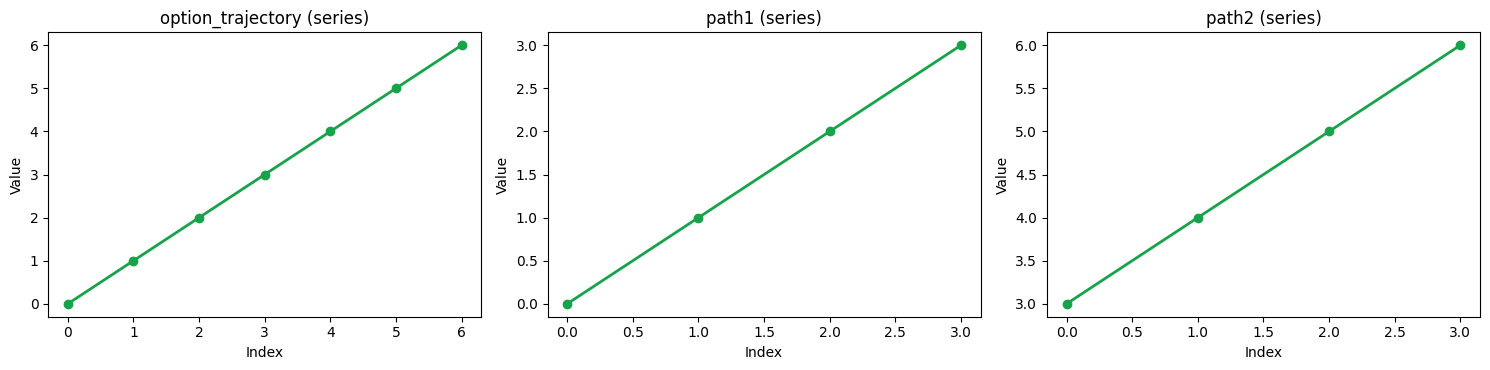

In [3]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Import names from a package/module into the notebook kernel namespace.
import numbers
# Import names from a package/module into the notebook kernel namespace.
import numpy as np
# Import names from a package/module into the notebook kernel namespace.
import matplotlib.pyplot as plt

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Return a value from this function to its caller.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # Branch: only run the next indented lines when this condition is true.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Return a value from this function to its caller.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Loop header: repeat the indented block for each item in the iterable.
    for item in value.values():
        # Branch: only run the next indented lines when this condition is true.
        if not _is_number(item):
            # Return a value from this function to its caller.
            return None
        # Append one value to a list (mutates the list in place).
        converted.append(float(item))
    # Return a value from this function to its caller.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Return a value from this function to its caller.
        return None
    # Branch: only run the next indented lines when this condition is true.
    if array.ndim != dims:
        # Return a value from this function to its caller.
        return None
    # Branch: only run the next indented lines when this condition is true.
    if dims == 1 and not (2 <= array.size <= 200):
        # Return a value from this function to its caller.
        return None
    # Branch: only run the next indented lines when this condition is true.
    if dims == 2 and array.size > 400:
        # Return a value from this function to its caller.
        return None
    # Return a value from this function to its caller.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math", "Figure", "fig"}
# Assign/update a variable used later in this cell or in other cells.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Loop header: repeat the indented block for each item in the iterable.
for name in search_space:
    # Branch: only run the next indented lines when this condition is true.
    if name in seen or name not in globals() or name in skip_names:
        # Skip the rest of this loop body and jump to the next iteration.
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # Branch: only run the next indented lines when this condition is true.
    if dict_payload is not None:
        # Append one value to a list (mutates the list in place).
        candidates.append(("dict", name, dict_payload))
        # Branch: only run the next indented lines when this condition is true.
        if len(candidates) == 3:
            # Exit the nearest enclosing loop immediately.
            break
        # Skip the rest of this loop body and jump to the next iteration.
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # Branch: only run the next indented lines when this condition is true.
    if array_2d is not None:
        # Append one value to a list (mutates the list in place).
        candidates.append(("heatmap", name, array_2d))
        # Branch: only run the next indented lines when this condition is true.
        if len(candidates) == 3:
            # Exit the nearest enclosing loop immediately.
            break
        # Skip the rest of this loop body and jump to the next iteration.
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # Branch: only run the next indented lines when this condition is true.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        # Skip misleading line plots for last-step env vectors (not time series).
        if name in {"obs", "next_obs", "state", "action"} and array_1d.size <= 16:
            continue
        candidates.append(("line", name, array_1d))
        # Branch: only run the next indented lines when this condition is true.
        if len(candidates) == 3:
            # Exit the nearest enclosing loop immediately.
            break

# Branch: only run the next indented lines when this condition is true.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "functions": sum(callable(value) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Configure a subplot axis (limits, ticks, labels, or artists).
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # More on the same axes object (limits, ticks, labels, artists).
    ax.set_title("Notebook artifact summary")
    # More on the same axes object (limits, ticks, labels, artists).
    ax.set_ylabel("Count")
    # Loop header: repeat the indented block for each item in the iterable.
    for idx, value in enumerate(summary.values()):
        # More on the same axes object (limits, ticks, labels, artists).
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.tight_layout()
    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.show()
# Else branch: runs when the matching if/elif chain was not taken.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # Branch: only run the next indented lines when this condition is true.
    if len(candidates) == 1:
        # Assign/update a variable used later in this cell or in other cells.
        axes = [axes]

    # Loop header: repeat the indented block for each item in the iterable.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # Branch: only run the next indented lines when this condition is true.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.bar(range(len(values)), values, color="#2563eb")
            # More on the same axes object (limits, ticks, labels, artists).
            ax.set_xticks(range(len(values)))
            # More on the same axes object (limits, ticks, labels, artists).
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # More on the same axes object (limits, ticks, labels, artists).
            ax.set_title(f"{name} (dict)")
            # More on the same axes object (limits, ticks, labels, artists).
            ax.set_ylabel("Value")
        # Else-if branch: checked only when previous conditions were false.
        elif kind == "line":
            # More on the same axes object (limits, ticks, labels, artists).
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # More on the same axes object (limits, ticks, labels, artists).
            ax.set_title(f"{name} (series)")
            # More on the same axes object (limits, ticks, labels, artists).
            ax.set_xlabel("Index")
            # More on the same axes object (limits, ticks, labels, artists).
            ax.set_ylabel("Value")
        # Else branch: runs when the matching if/elif chain was not taken.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # More on the same axes object (limits, ticks, labels, artists).
            ax.set_title(f"{name} (heatmap)")
            # Configure or update the active Matplotlib Figure object.
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.tight_layout()
    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** Hierarchical RL breaks long tasks into reusable sub-skills so the agent can reason at more than one level of abstraction.

**If students remember one idea:** Options are useful because real tasks often need meaningful intermediate behaviors, not only one-step decisions.

**Quick check before moving on:**
- Can you explain how an option differs from a single primitive action?
- Can you describe why hierarchy can help with long-horizon problems?

**Bridge to the next step:** The next lesson changes perspective again by learning a model of the world and planning with it.
